## Módulo 04: Red Neuronal Artificial (ANN) - Clasificador de Recomendación de Pesca
Entrenado con un dataset sintético basado en `make_classification` + Reglas de INCOPESCA.


# 1. Importacion de los datos


In [1]:
import os
import sys
from pathlib import Path

# Raiz del repo: permite correr el notebook desde cualquier directorio
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src" / "train"))
os.chdir(ROOT)

import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from ann import entrenar_red_neuronal

# Configuración del estilo visual para los gráficos
sns.set_theme(style="whitegrid")
print("Librerías importadas y entorno configurado correctamente.")

Librerías importadas y entorno configurado correctamente.


# 2. Ejecucion del entremaniento del modelo

In [2]:
# Ejecutar el entrenamiento completo directamente desde el script exterior
entrenar_red_neuronal()

iniciando el pipeline de entrenamiento de la ann
[1/5] generando pool sintético con variables independientes...
[2/5] aplicando etiquetado supervisado (reglas incopesca)...
[3/5] balanceando el dataset por clase...
   pool crudo: {0: np.int64(156087), 1: np.int64(20850), 2: np.int64(19050), 3: np.int64(4013)}
   balanceado: {0: np.int64(2000), 1: np.int64(2000), 2: np.int64(2000), 3: np.int64(2000)}


[4/5] entrenando el perceptrón multicapa (ann)...


 ¡modelo entrenado con éxito! precisión en test: 99.06%
                   precision    recall  f1-score   support

regresar a puerto       1.00      0.98      0.99       400
        no pescar       0.99      1.00      1.00       400
       precaución       0.99      0.99      0.99       400
      recomendada       0.99      0.99      0.99       400

         accuracy                           0.99      1600
        macro avg       0.99      0.99      0.99      1600
     weighted avg       0.99      0.99      0.99      1600

[5/5] exportando archivos binarios (.pkl)...
proceso finalizado. archivos listos en /models


In [3]:
# Carga de los archivos binarios guardados en disco
modelo_ann = joblib.load("models/ann_clasificador_pesca.pkl")
scaler_ann = joblib.load("models/scaler_ann_pesca.pkl")
print(" Modelo y escalador cargados con éxito desde la carpeta /models.")

 Modelo y escalador cargados con éxito desde la carpeta /models.


# 3. Generación de Datos de Prueba y Prediccion

In [4]:
import pandas as pd
import numpy as np

# Set de prueba con las MISMAS variables y rangos que src/train/ann.py.
# No se usa make_classification: devuelve valores centrados en 0, fuera de
# las unidades marinas sobre las que se ajusto scaler_ann.
rng = np.random.default_rng(99)
columnas = ["altura", "viento", "sst", "distancia", "especie", "veda", "amp"]

pool = pd.DataFrame({
    "altura":    rng.uniform(0.0, 5.0, 200_000),
    "viento":    rng.uniform(0.0, 80.0, 200_000),
    "sst":       rng.uniform(22.0, 32.0, 200_000),
    "distancia": rng.uniform(1.0, 80.0, 200_000),
    "especie":   rng.integers(0, 8, 200_000),
    "veda":      rng.binomial(1, 0.25, 200_000),
    "amp":       rng.binomial(1, 0.20, 200_000),
})

# Etiqueta REAL: las mismas reglas INCOPESCA con las que se entreno el modelo
condiciones = [
    (pool["altura"] > 2.5) | (pool["viento"] > 35),                    # 0 regresar a puerto
    (pool["veda"] == 1) | (pool["amp"] == 1) | (pool["especie"] == 7), # 1 no pescar
    (pool["altura"] > 1.8) | (pool["viento"] > 25),                    # 2 precaucion
    (pool["sst"].between(26.0, 30.0)) & (pool["altura"] < 1.5),        # 3 recomendada
]
pool["target"] = np.select(condiciones, [0, 1, 2, 3], default=2)

# 250 por clase = 1000 muestras, para que el reporte no lo domine una sola clase
partes = [g.sample(n=250, random_state=99) for _, g in pool.groupby("target")]
muestra = pd.concat(partes).sample(frac=1, random_state=99).reset_index(drop=True)

x_df = muestra[columnas]
y_test_real = muestra["target"].values

# Escalar con el MISMO scaler del entrenamiento y predecir
x_test_scaled = pd.DataFrame(scaler_ann.transform(x_df), columns=columnas)
y_test_pred = modelo_ann.predict(x_test_scaled)

# Etiquetas oficiales para los reportes y ejes graficos
target_names = ["regresar a puerto", "no pescar", "precaucion", "pesca recomendada"]
print(f" Set de prueba: {len(x_df)} muestras, {len(np.unique(y_test_real))} clases balanceadas ")


 Set de prueba: 1000 muestras, 4 clases balanceadas 


## 4. Reporte de Clasificación
Visualizamos la precisión, recall y F1-score del modelo para cada una de las 4 categorías operativas de pesca.

In [5]:
print("================ REPORTES DE CLASIFICACIÓN DE LA ANN ================\n")
print(classification_report(y_test_real, y_test_pred, target_names=target_names))

================ REPORTES DE CLASIFICACIÓN DE LA ANN ================

                   precision    recall  f1-score   support

regresar a puerto       1.00      0.98      0.99       250
        no pescar       0.99      1.00      0.99       250
       precaucion       0.98      0.97      0.98       250
pesca recomendada       0.97      1.00      0.99       250

         accuracy                           0.99      1000
        macro avg       0.99      0.99      0.99      1000
     weighted avg       0.99      0.99      0.99      1000



## 5. Visualización del Rendimiento del Modelo de Reconocimiento de Peces

###Curva de Pérdida (Loss Curve)
Como `MLPClassifier` no guarda la precision por epoca de forma nativa, graficamos la curva de pérdida (`loss_curve_`) para asegurarnos de que el optimizador Adam convergió correctamente y la pérdida disminuyó consistentemente.

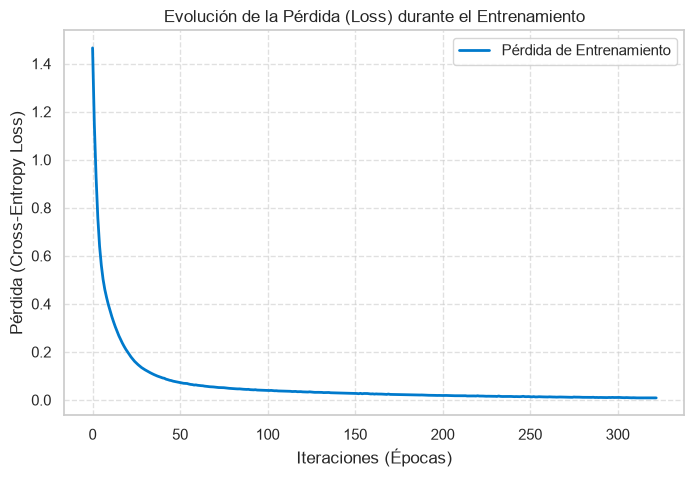

In [6]:
# Carga del modelo entrenado
ann_model = joblib.load("models/ann_clasificador_pesca.pkl")

#Graficar la curva de perdida acumulada por iteracion
plt.figure(figsize=(8, 5))
plt.plot(ann_model.loss_curve_, color='#007acc', linewidth=2, label='Pérdida de Entrenamiento')
plt.title('Evolución de la Pérdida (Loss) durante el Entrenamiento')
plt.xlabel('Iteraciones (Épocas)')
plt.ylabel('Pérdida (Cross-Entropy Loss)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### Matriz de Confusión
Graficamos una matriz de confusión en formato Heatmap para analizar visualmente los aciertos del clasificador y dónde se están concentrando las desviaciones entre las clases reales y las predicciones.

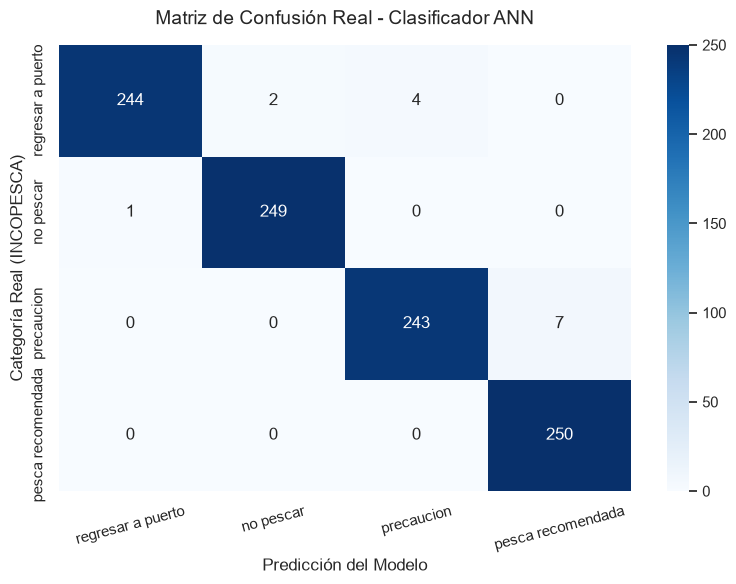

In [7]:
# Calculo de la matriz de confusion pasando los datos reales vs las predicciones
cm = confusion_matrix(y_test_real, y_test_pred)

# Configuracion y despliegue del grafico estadístico
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)

plt.title("Matriz de Confusión Real - Clasificador ANN", fontsize=14, pad=15)
plt.ylabel("Categoría Real (INCOPESCA)", fontsize=12)
plt.xlabel("Predicción del Modelo", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()